## Esfinge: Modelo de comitê usando a abordagem Bagging e Meta Aprendizado

Aluno: Gabriel de Oliveira Paiva

O modelo de comitê é um modelo que funciona como um "comitê de modelos", onde suas respostas são algum tipo de combinação ou alguma resposta específica ( mais votada ) dos modelos envolvidos nele. Neste notebook usaremos como exemplo um comitê que será composto por um modelo de KNN, uma floresta aleatória e uma árvore de decisão. Será feito também um modelo Baseline para comparação de nosso modelo final. 

Neste notebook utilizaresmo os dados de pinguins apresentados durante a disciplina e disponível no módulo `seaborn` e a biblioteca destinada a aprendizado de máquina `scikit-learn`

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.utils import resample
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

### Por que não usar sempre modelos individuais?

Essa pergunta é um tanto quanto coerente, se tenho um modelo e ele possui um bom desempenho, porque usar mais do que ele sozinho? Modelos nunca são perfeitos, e seus erros são ligados a forma com que são treinados e a própria estrutura que os torna o modelo que são. Por isso um modelo do tipo A pode ter um desempenho mais baixo em uma situação que o do tipo B funciona muito bem, e vice-versa. A analogia que modelos são super-heróis e que cada um tem sua prórpia "Criptonita" pode ajudar a compreender esta ideia. É importante lembrar que mesmo em que esse não seja o caso, um comitê possui algumas características estatísticas que podem ser úteis, justificando seu uso. Vamos ver essas situações para os modelos que usaremos neste material didático

**Floresta Aleatória**

É um modelo considerado robusto, mas pode não ser muito eficiente em situações em que o número de dados é pequeno, quando há muitos atributos irrelevantes ou quando a relação entre os dados é muito suave. Também pode apresentar dificuldades em problemas com classes muito desbalanceadas e, em tarefas de regressão não costuma ir bem em extrapolações fora do "alcance" de seu treinamento como se ele for treinado por um banco de dados de pessoas entre 20 e 60 anos, ele provavelmente terá dificuldade de prever características de pessoas fora desta faixa

**KNN**

É um modelo simples e que é muito útil, mas pode apresentar dificuldades quando há muitos atributos, pois as distâncias entre os exemplos tendem a se tornar menos informativas.

**Árvore de decisão**

 Pode ser bastante sensível aos dados utilizados no treinamento ( O que em excesso pode ser ruim e levar ao overfitting) enquanto árvores muito simples podem não capturar adequadamente os padrões presentes nos dados. Além disso, pequenas alterações nos dados podem gerar árvores bastante diferentes, tornando o modelo mais instável.

Ao combinar estes 3 modelos em um comitê, esperamos que eles se complementem e que comitê se torne mais confiável e polivalente para analisar diferentes conjuntos de dados e que aumente sua eficácia de modo geral, mas com que estrátegia treinamos eles pensando em um comitê e não como modelos independentes?

### Relembrando alguns conceitos...

Aqui temos uma breve definição de alguns conceitos básicos que acredito eu que você já tenha tido contato, caso tenha alguma dúvida ou insegurança recomendo que revisite os notebooks do Professor Cassar que os abordam de forma mais profunda e completa.

**Viés:**

 O viés está relacionado aos erros causados por simplificações excessivas do modelo. Quando o modelo é muito simples, ele pode não conseguir aprender os padrões mais importantes dos dados, resultando em um desempenho abaixo do esperado. Esse comportamento é conhecido como underfitting.

**Variância:**

 A variância representa o quanto as previsões de um modelo mudam quando há pequenas alterações nos dados de treinamento. Modelos com alta variância tendem a se adaptar demais aos exemplos utilizados no treinamento, capturando até mesmo ruídos e particularidades dos dados. Esse fenômeno é chamado de overfitting e geralmente reduz a capacidade de generalização do modelo.

**Equilíbrio Viés–Variância:** 

O equilíbrio entre viés e variância consiste em encontrar um nível adequado de complexidade para o modelo. Modelos muito simples podem apresentar alto viés, enquanto modelos muito complexos podem apresentar alta variância. O objetivo é obter um modelo capaz de aprender os padrões relevantes dos dados sem se ajustar excessivamente aos detalhes específicos do conjunto de treinamento.

**Covariância:** 

A covariância mede como duas variáveis variam em conjunto. Quando ambas tendem a aumentar ou diminuir simultaneamente, a covariância assume valores positivos; quando se comportam em direções opostas, assume valores negativos. Em Ensemble Learning, esse conceito ajuda a analisar o quanto diferentes modelos apresentam comportamentos ou erros semelhantes.

**Correlação:** 

A correlação indica a força e a direção da relação entre duas variáveis em uma escala padronizada. Valores próximos de 1 indicam uma forte relação positiva, enquanto valores próximos de -1 indicam uma forte relação negativa. Em ensembles, modelos com baixa correlação entre seus erros costumam contribuir mais para a melhoria do desempenho, pois fornecem previsões mais diversificadas.

### O que é o Bagging

Você pode usar várias estrátegias diferentes mas no nosso caso usaremos o _bagging_ ( abreviação para _Bootstrap Aggregating_) que consiste em treinar nossos modelos com partes dos nossos dados, essas partes não são iguais, mas podem conter exemplos em comum.

Representação do Bagging

<img alt="célula" src="https://www.oreilly.com/api/v2/epubs/urn:orm:book:9781788830577/files/assets/a942be0b-22b5-45c0-9fbf-007ec88a7e7e.png" width="500px">

***Fonte:https://www.oreilly.com/library/view/machine-learning-quick/9781788830577/6f97f4fd-5b34-4d7b-bb48-ec156c6262b1.xhtml***

Certo, agora vamos entender o como isso funciona e porque faz sentido:

vamos supor que treinaremos:

$$ f_1(x), f_2(x), \ldots, f_B(x) $$
Para cada $f_i(x)$ é feito um treinamento com um bootstrap diferente, ou seja cada modelo pode realizar uma previsão diferente para um mesmo x
por exemplo: $$f_a(x)=10$$ $$f_b(x)=11$$ $$f_c(x)=9$$
A partir disso o Bagging faz a média, ou seja:
$${f}_{bag}(x) = \frac{1}{B}\sum_{b=1}^{B} f_b(x)$$

A resposta nesse caso seria a média dos valores considerando cada voto do comitê. Discutiremos sobre a combinação das respostas mais a fundo adiante, não se preocupe muito com isso agora a ideia é o uso de um exemplo para o Baggin, Essas são as operações básicas que ele pode fazer no caso de serem modelos de regressão, mas como isso afeta a variância e o viés do comitê?

Podemos representar cada previsão de um modelo individual como $${f}_{bag} = f(x) + \varepsilon_b$$

 Assim, a predição obtida pelo Bagging é dada pela média das previsões dos $B$ modelos, ou seja,
 
  $${f}_{bag} = \frac{1}{B}\sum_{b=1}^{B}[f(x)+\varepsilon_b]$$
  
   Distribuindo a soma, obtém-se:
   $${f}_{bag} = f(x) + \frac{1}{B}\sum_{b=1}^{B}\varepsilon_b$$
   
   Dessa forma, o erro do comitê pode ser escrito como a média dos erros dos modelos envolvidos $$\varepsilon_{bag} = \frac{1}{B}\sum_{b=1}^{B}\varepsilon_b$$ 
    
mostrando que o Bagging transforma o erro do comitê na média dos erros dos modelos individuais. Para analisar a variância do método, consideramos a variância da predição agregada, dada por $$\mathrm{Var}({f}_{bag}) = \mathrm{Var}\left(\frac{1}{B}\sum_{b=1}^{B}{f}_{bag}\right)$$ Aplicando a propriedade $$\mathrm{Var}(aX) = a^2\mathrm{Var}(X)$$ obtemos: $$\mathrm{Var}({f}_{bag}) = \frac{1}{B^2}\mathrm{Var}\left(\sum_{b=1}^{B}{f}_{bag}\right)$$


No caso ideal considerando que os modelos são independentes, temos
 $$\operatorname{Cov}({f}_{a},{f}_{b})=0,\quad {f}_{a}\neq {f}_{b}.$$
  Então, a variância da média dos modelos é dada por

   $$\operatorname{Var}({f}_{bag})=\frac{1}{B^2}\sum_{i=1}^{B}\operatorname{Var}({f}_b).$$

Se todos os modelos possuem a mesma variância, isto é:
 $$\operatorname{Var}({f}_{a})=\sigma^2,$$ 
então obtemos:
 $$\operatorname{Var}({f}_{bag})=\frac{1}{B^2}B\sigma^2=\frac{\sigma^2}{B}.$$ 
Portanto: 
$${\operatorname{Var}({f}_{bag})=\frac{\sigma^2}{B}}$$ 
A quantidade de modelos é inversamente proporcional a variância no Bagging para regressão. Assim, quando aumentamos o número de modelos em um comitê tendemos a diminuir a variância do comitê. Porém nossos modelos não são totalmente independentes já que são treinados com partes diferentes dos mesmos dados, por isso temos que:
  $$\operatorname{Corr}({f}_{a},{f}_{b})=\rho.$$
  Como:
  $$\operatorname{Cov}({f}_{a},{f}_{b})=\rho\sigma^2,$$
  podemos chegar a:
  $$\operatorname{Var}({f}_{bag})=\frac{\sigma^2}{B}+\frac{B-1}{B}\rho\sigma^2,$$
  Reorganizando, obtemos
  $${\operatorname{Var}({f}_{bag})=\sigma^2\left(\rho+\frac{1-\rho}{B}\right)}.$$

Agora podemos fazer outra dedução importante. A média do comitê é dada por

$$
E[{f}_{bag}] = E\left[\frac{1}{B}\sum_{b=1}^{B}{f}_b\right].
$$

Pela linearidade da esperança,

$$
E[{f}_{bag}] = \frac{1}{B}\sum_{b=1}^{B}E[{f}_b].
$$

Se todos os modelos possuem o mesmo viés,

$$
\operatorname{Viés}({f}_{b})=\beta,
$$

então:

$$
\operatorname{Viés}({f}_{bag})=\beta.
$$

Ou seja, o Bagging é especialmente eficiente para reduzir a variância, mas não necessariamente reduz o viés. 

Para regressão, o erro quadrático médio (MSE) do comitê pode ser escrito como

$$
MSE = \operatorname{Viés}^2 + \operatorname{Var} + \sigma_{\varepsilon}^{2}.
$$

Vale ressaltar que aumentar o número de modelos indefinidamente reduz a variância até um certo ponto, ou seja um número de modelos tendendo a infinito a variância não será zero, e será ainda maior se eles forem correlacionados entre si (O que acontece na maioria das vezes)

Agora vamos entender como o comitê e suas características se aplicam quando temos um problema de classificação. Para este exemplo usaremos a associação na ideia de votação majoritária mas não se preocupe com isso neste momento, falaremos mais sobre essa temática adiante

$$
Y \in \{0,1\}.
$$

Cada modelo produz:

$$
f_b(x) \in \{0,1\}.
$$

O Bagging utilizando votação majoritária:

$$
{f}_{bag} = \operatorname{modelo}\left\{f_1(x),f_2(x),\ldots,f_b(x)\right\}.
$$

Aqui temos uma dedução muito interessante. Suponha que cada modelo tenha probabilidade de erro

$$
P(\text{erro}) = p.
$$

Se assumirmos, para simplificar, que os erros são independentes, o comitê comete erro quando mais da metade dos modelos erram.

Para $B$ modelos ímpares:

$$
P(\text{erro do comitê})
=
\sum_{k=(B+1)/2}^{B}
\binom{B}{k}
p^k(1-p)^{B-k}.
$$

Essa equação é a versão classificatória da redução de variância.


Imagine que temos 100 modelos, mas todos cometem praticamente os mesmos erros. Por exemplo,

$$
f_1(x)=f_2(x)=\cdots=f_{100}(x)
$$

Então,

$$
\rho \approx 1
$$

A votação não acrescenta praticamente nenhuma informação. É quase como ter

$$
1 \text{ modelo} \times 100
$$

Por outro lado, se os modelos cometem erros diferentes,

$$
\rho \approx 0
$$

a votação consegue cancelar parte desses erros.

Portanto,

$$
\text{Baixa correlação entre erros} \Rightarrow \text{maior benefício do Bagging}
$$

Ou seja modelos que erram de formas não correlacionadas formam um comitê que tende a errar menos, isso nos explicita a importância que a variedade de modelos tem para a formação de um bom comitê

### Limitações e ponderações do Comitê com Baggin

A principal característica do Bagging como vimos acima é diminuir a variância, o que o torna menos sensível a particularidades do conjunto de treinamento, porém isso não protege o nosso comitê de ter problemas com relação ao **viés**. Por exemplo um comitê formado por um conjunto de modelos muito simples podem apresentar alto viés mas fazer um comitê deles não resolve o problema da baixa flexibilidade dos modelos e consequentemente do comitê.

**Diferença entre modelos** : É um ponto fundamental para entendermos quando devemos ou não usar o comitê com Bagging, se os seus modelos forem muito semelhantes apenas o treinamento com diferentes porções dos dados pode não ser suficiente para diversificar as respostas dos modelos, o que faz com que oganho em perda de variãncia seja muito pequeno quando comparado aos modelos individuais.

**Custo computacional** Caso seu comitê tenha muitos modelos ou o ganho com a combinação deles seja pequeno talvez não faça sentido o custo adicional de treinar vários modelos e combiná-los no lugar de treinar apenas um modelo.

**Interpretação** A depender dos critérios de votação e do número de modelos pode se tornar um modelo não tão simples de interpretar ou de entender o porquê que o modelo se comporta de jeito x em determinada situação

### Ajustando o Banco de Dados

Sabemos que precisamos entender e trabalhar nossos dados antes de treinar nossos modelos, então vamos lá!
Nossos dados são sobre chapas de aços e suas características! Ele foi obtido por meio de um site com várias opções indicado pelo professor Cassar! Você pode acessa-lô nas referências!

Conhecendo nosso dados:

In [108]:
nome_do_arquivo = "Falha_de_chapas_de_aço.csv"
df = pd.read_csv(nome_do_arquivo)
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,1.403271,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.454345,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,0.000000,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,1.079200,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,1.322200,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,1.732400,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,4.258700,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Significado de cada coluna:
- V1: X_Mínimo
- V2: X_Máximo
- V3: Y_Mínimo
- V4: Y_Máximo
- V5: Área em Pixels
- V6: Perímetro em X
- V7: Perímetro em Y
- V8: Soma da Luminosidade
- V9: Luminosidade Mínima
- V10: Luminosidade Máxima
- V11: Comprimento da Esteira Transportadora
- V12: Tipo de Aço A300
- V13: Tipo de Aço A400
- V14: Espessura da Chapa de Aço
- V15: Índice de Bordas
- V16: Índice de Vazio
- V17: Índice de Quadratura
- V18: Índice Externo em X
- V19: Índice de Bordas em X
- V20: Índice de Bordas em Y
- V21: Índice Global Externo
- V22: Logaritmo das Áreas
- V23: Logaritmo do Índice X
- V24: Logaritmo do Índice Y
- V25: Índice de Orientação
- V26: Índice de Luminosidade
- V27: Sigmoide das Áreas
- V28: Inclusões de Pastry
- V29: Arranhão em Z
- V30: Arranhão em K
- V31: Manchas
- V32: Sujeira
- V33: Saliências
- Classe: Outras Falhas

In [109]:
df = df.dropna()
ATRIBUTOS = ["V1", # X_Mínimo
"V3", # Y_Mínimo
"V5", # Área em Pixels
"V11", # Comprimento da Esteira
"V14", # Espessura da Chapa
"V15", # Índice de Bordas
"V25", # Índice de Orientação
]
TARGET = ["V10"]
X = df[ATRIBUTOS]
y = df[TARGET]

In [110]:
X

,V1,V3,V5,V11,V14,V15,V25
0,42.0,270900.0,267.0,1687.0,80.0,0.0498,0.8182
1,645.0,2538079.0,108.0,1687.0,80.0,0.7647,0.7931
2,829.0,1553913.0,71.0,1623.0,100.0,0.9710,0.6667
3,853.0,369370.0,176.0,1353.0,290.0,0.7287,0.8444
4,1289.0,498078.0,2409.0,1353.0,185.0,0.0695,0.9338
...,...,...,...,...,...,...,...
1936,249.0,325780.0,273.0,1360.0,40.0,0.3662,-0.4286
1937,144.0,340581.0,287.0,1360.0,40.0,0.2118,-0.4516
1938,145.0,386779.0,292.0,1360.0,40.0,0.2132,-0.4828
1939,137.0,422497.0,419.0,1360.0,40.0,0.2015,-0.0606


In [111]:
y

,V10
0,108.0
1,123.0
2,125.0
3,126.0
4,126.0
...,...
1936,141.0
1937,133.0
1938,140.0
1939,140.0


In [112]:
# Criando Arrays e garantindo que o y tenha 1 dimensão
X_array = X.values
y_array = y.values.ravel()

### O modelo KNN

Vamos treinar dois modelos para nosso estudo! Um modelo KNN pensado para atuar sozinho e outro para construirmos nosso comitê utilizando Bagging.

Primeiro vamos treinar o que vai atuar sozinho:

Aqui definimos o tamanho do grupo de teste e a semente aleatória que será usada nos nosso modelos individuais e veremos as dimensões dos nossos grupos de treino e teste

In [113]:
TAMANHO_TESTE = 0.1 # Esse valor será usado em todos os modelos individuais
SEMENTE_ALEATORIA = 42 # Esse valor será usado em todos os modelos individuais
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_array,
    y_array,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (1746, 7)
X_teste: (195, 7)
y_treino: (1746,)
y_teste: (195,)


Sabemos que o modelo KNN é extremamente sensível ao número de vizinhos que ele considerará para realizar suas previsões, se a distância influenciará no peso desses vizinhos e qual métrica de distância usaremos, por isso veremos uma combinação desses hiperparâmetros que produz um menor MSE dentre os testados.

In [114]:
NUM_FOLDS = 10
NUM_ITERACOES = 100

espaco_de_busca = {
    "n_neighbors": range(1, 51),
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

modelo= KNeighborsRegressor()

buscador = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=espaco_de_busca,
    n_iter=NUM_ITERACOES,
    cv=NUM_FOLDS,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    refit=True,
    n_jobs=-1
)

buscador.fit(X_treino, y_treino)

resultados_knn = pd.DataFrame(
    buscador.cv_results_
)

resultados_knn["rmse"] = (
    -resultados_knn["mean_test_score"]
)

top15_knn = resultados_knn.sort_values(
    "rmse"
).head(15)

print("\nTOP 15 - KNN\n")

print(
    top15_knn[
        [
            "param_n_neighbors",
            "param_weights",
            "param_p",
            "rmse"
        ]
    ].to_string(index=False)
)

print("\nMELHOR CONFIGURAÇÃO\n")

print(buscador.best_params_)

print(
    f"\nMelhor RMSE: {-buscador.best_score_:.4f}"
)

knn = buscador.best_estimator_


TOP 15 - KNN

 param_n_neighbors param_weights  param_p      rmse
                48       uniform        2 18.172023
                49       uniform        2 18.172507
                47       uniform        2 18.172747
                46       uniform        2 18.175717
                44       uniform        1 18.201385
                44       uniform        2 18.211683
                42       uniform        1 18.211977
                43       uniform        2 18.215363
                41       uniform        2 18.224814
                40       uniform        2 18.246861
                39       uniform        1 18.251944
                36       uniform        1 18.281191
                38       uniform        2 18.284076
                35       uniform        1 18.284827
                38       uniform        1 18.287044

MELHOR CONFIGURAÇÃO

{'weights': 'uniform', 'p': 2, 'n_neighbors': 48}

Melhor RMSE: 18.1720


Agora vamos aplicar este número em nosso modelo!

In [115]:
knn = buscador.best_estimator_

y_pred_knn = knn.predict(X_teste)

rmse = root_mean_squared_error(
    y_teste,
    y_pred_knn
)

print(rmse)

22.11169305635315


Vamos visualizar em um gráfico o desempenho de nosso modelo, lembre-se que os pontos em azul são os valores previstos pelo modelo e a reta indica quando o resultado estaria correto ( Previsão = Valor do teste).

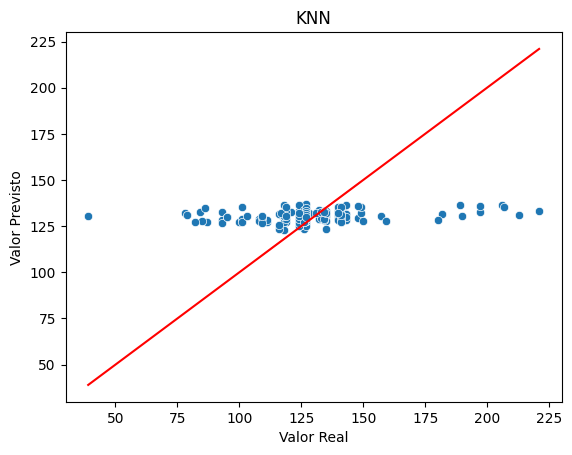

In [116]:
sns.scatterplot(
    x=y_teste,
    y=y_pred_knn
)

sns.lineplot(
    x=y_teste,
    y=y_teste,
    color="red"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("KNN")
plt.show()

### A Árvore de Decisão

Vamos criar agora nosso modelo de árvore de decisão! Começaremos com as configurações iniciais já combinadas.

In [117]:
# Mesma estrutura utilizada anteriormente, deixada aqui só para registro
TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 42
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_array,
    y_array,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (1746, 7)
X_teste: (195, 7)
y_treino: (1746,)
y_teste: (195,)


Agora vamos percorre algumas combinações para profundidade, número de folhas, mínimo de amostras para termos um nó e mínimo de amostras em uma folha.Para encontrarmos uma boa configuração para nosso modelo, lembrando que esse passo é de extrema importância, pois um modelo muito simples tem dificuldade em captar os padrões nos dados enquanto o contrário pode sofrer por se apegar demais aos dados e perder a capacidade de generalização. Utilizaremos a busca aleatória para esta tarefa!

In [118]:
NUM_FOLDS = 10
NUM_ITERACOES = 100

espaco_de_busca = {
    "max_depth": [None] + list(range(1, 21)),
    "min_samples_split": range(2, 21),
    "min_samples_leaf": range(1, 11),
    "max_leaf_nodes": [None] + list(range(2, 51))
}

modelo = DecisionTreeRegressor(
    random_state=42
)

buscador = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=espaco_de_busca,
    n_iter=NUM_ITERACOES,
    cv=NUM_FOLDS,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    refit=True,
    n_jobs=-1
)

buscador.fit(X_treino, y_treino)

resultados_arvore = pd.DataFrame(
    buscador.cv_results_
)

resultados_arvore["rmse_cv"] = (
    -resultados_arvore["mean_test_score"]
)

top15_arvore = resultados_arvore.nsmallest(
    15,
    "rmse_cv"
).copy()

avaliacoes = []

for _, linha in top15_arvore.iterrows():

    modelo_temp = DecisionTreeRegressor(
        max_depth=linha["param_max_depth"],
        min_samples_split=linha["param_min_samples_split"],
        min_samples_leaf=linha["param_min_samples_leaf"],
        max_leaf_nodes=linha["param_max_leaf_nodes"],
        random_state=42
    )

    modelo_temp.fit(X_treino, y_treino)

    y_pred_treino = modelo_temp.predict(X_treino)
    y_previsao_Arv = modelo_temp.predict(X_teste)

    rmse_treino = root_mean_squared_error(
        y_treino,
        y_pred_treino
    )

    rmse_teste = root_mean_squared_error(
        y_teste,
        y_previsao_Arv
    )

    avaliacoes.append({
        "profundidade": linha["param_max_depth"],
        "min_split": linha["param_min_samples_split"],
        "min_leaf": linha["param_min_samples_leaf"],
        "max_folhas": linha["param_max_leaf_nodes"],
        "rmse_cv": linha["rmse_cv"],
        "rmse_treino": rmse_treino,
        "rmse_teste": rmse_teste,
        "diferenca": abs(
            rmse_treino - rmse_teste
        )
    })

df_final = pd.DataFrame(avaliacoes)

df_final = df_final.sort_values(
    "rmse_teste"
)

melhor_equilibrado = df_final.loc[
    df_final["diferenca"].idxmin()
]

print("\nTOP 15 MODELOS\n")

print(df_final.to_string(index=False))

print("\nMELHOR EQUILIBRADO ENTRE OS 15\n")

print(
    f"Profundidade: {melhor_equilibrado['profundidade']}\n"
    f"Min Samples Split: {melhor_equilibrado['min_split']}\n"
    f"Min Samples Leaf: {melhor_equilibrado['min_leaf']}\n"
    f"Max Leaf Nodes: {melhor_equilibrado['max_folhas']}\n"
    f"RMSE CV: {melhor_equilibrado['rmse_cv']:.4f}\n"
    f"RMSE treino: {melhor_equilibrado['rmse_treino']:.4f}\n"
    f"RMSE teste: {melhor_equilibrado['rmse_teste']:.4f}\n"
    f"Diferença: {melhor_equilibrado['diferenca']:.4f}"
)

arvore = DecisionTreeRegressor(
    max_depth=int(melhor_equilibrado["profundidade"]),
    min_samples_split=int(melhor_equilibrado["min_split"]),
    min_samples_leaf=int(melhor_equilibrado["min_leaf"]),
    max_leaf_nodes=int(melhor_equilibrado["max_folhas"]),
    random_state=42
)

arvore.fit(X_treino, y_treino)


TOP 15 MODELOS

 profundidade  min_split  min_leaf  max_folhas   rmse_cv  rmse_treino  rmse_teste  diferenca
         16.0         15         9          41 15.129094    11.856065   15.619642   3.763578
         16.0         20         9          25 15.083888    12.718098   15.971730   3.253632
         11.0         13         4          31 14.973365    12.107287   16.023379   3.916092
          8.0          6         7          45 15.132112    11.781434   16.112711   4.331277
         14.0          7         9          23 15.071968    12.864698   16.144400   3.279702
          8.0         16        10          49 15.077297    11.904666   16.212211   4.307544
          NaN         16         3          47 15.106213    11.080263   16.270208   5.189945
          8.0         13         5          22 15.096637    12.877870   16.272945   3.395075
         10.0         16        10          44 14.983549    11.762353   16.310596   4.548244
          9.0         18        10          31 15.103

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",9
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",25
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features

In [119]:
modelo_arvore_individual = arvore

y_previsao = modelo_arvore_individual.predict(X_teste)

rmse_teste = root_mean_squared_error(
    y_teste,
    y_previsao_Arv
)

print(rmse_teste)

16.11271145116337


Conferindo o RMSE de teste e o comparando com o de treino:

In [120]:
# Previsões
y_pred_treino_Arv = modelo_arvore_individual.predict(X_treino)
y_pred_teste_Arv = modelo_arvore_individual.predict(X_teste)

# RMSE
rmse_treino_Arv = root_mean_squared_error(y_treino, y_pred_treino_Arv)
rmse_teste_Arv = root_mean_squared_error(y_teste, y_pred_teste_Arv)

print(f"RMSE treino: {rmse_treino_Arv:.4f}")
print(f"RMSE teste : {rmse_teste_Arv:.4f}")

RMSE treino: 12.7181
RMSE teste : 15.9717


Isso nos indica que o modelo possivelmente possui Overfitting em algum grau, mas parece totalmente plausível, o escolhemos por ter essa característica de forma razoável e possui o menor RMSE disponível nos valores testados. 

Vamos agora visualizar os resultados da previsão e comparálos com os valores corretos

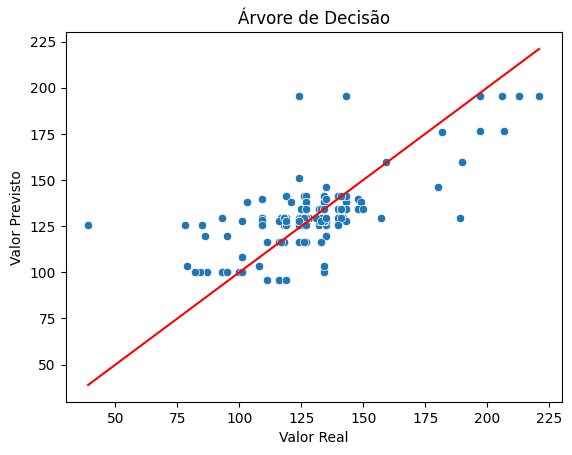

In [121]:
sns.scatterplot(
    x=y_teste,
    y=y_pred_teste_Arv
)
sns.lineplot(
    x=y_teste,
    y=y_teste,
    color="red"
)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Árvore de Decisão")
plt.show()

Vamos visualizar também como ficou a configuração de nossa árvore!!

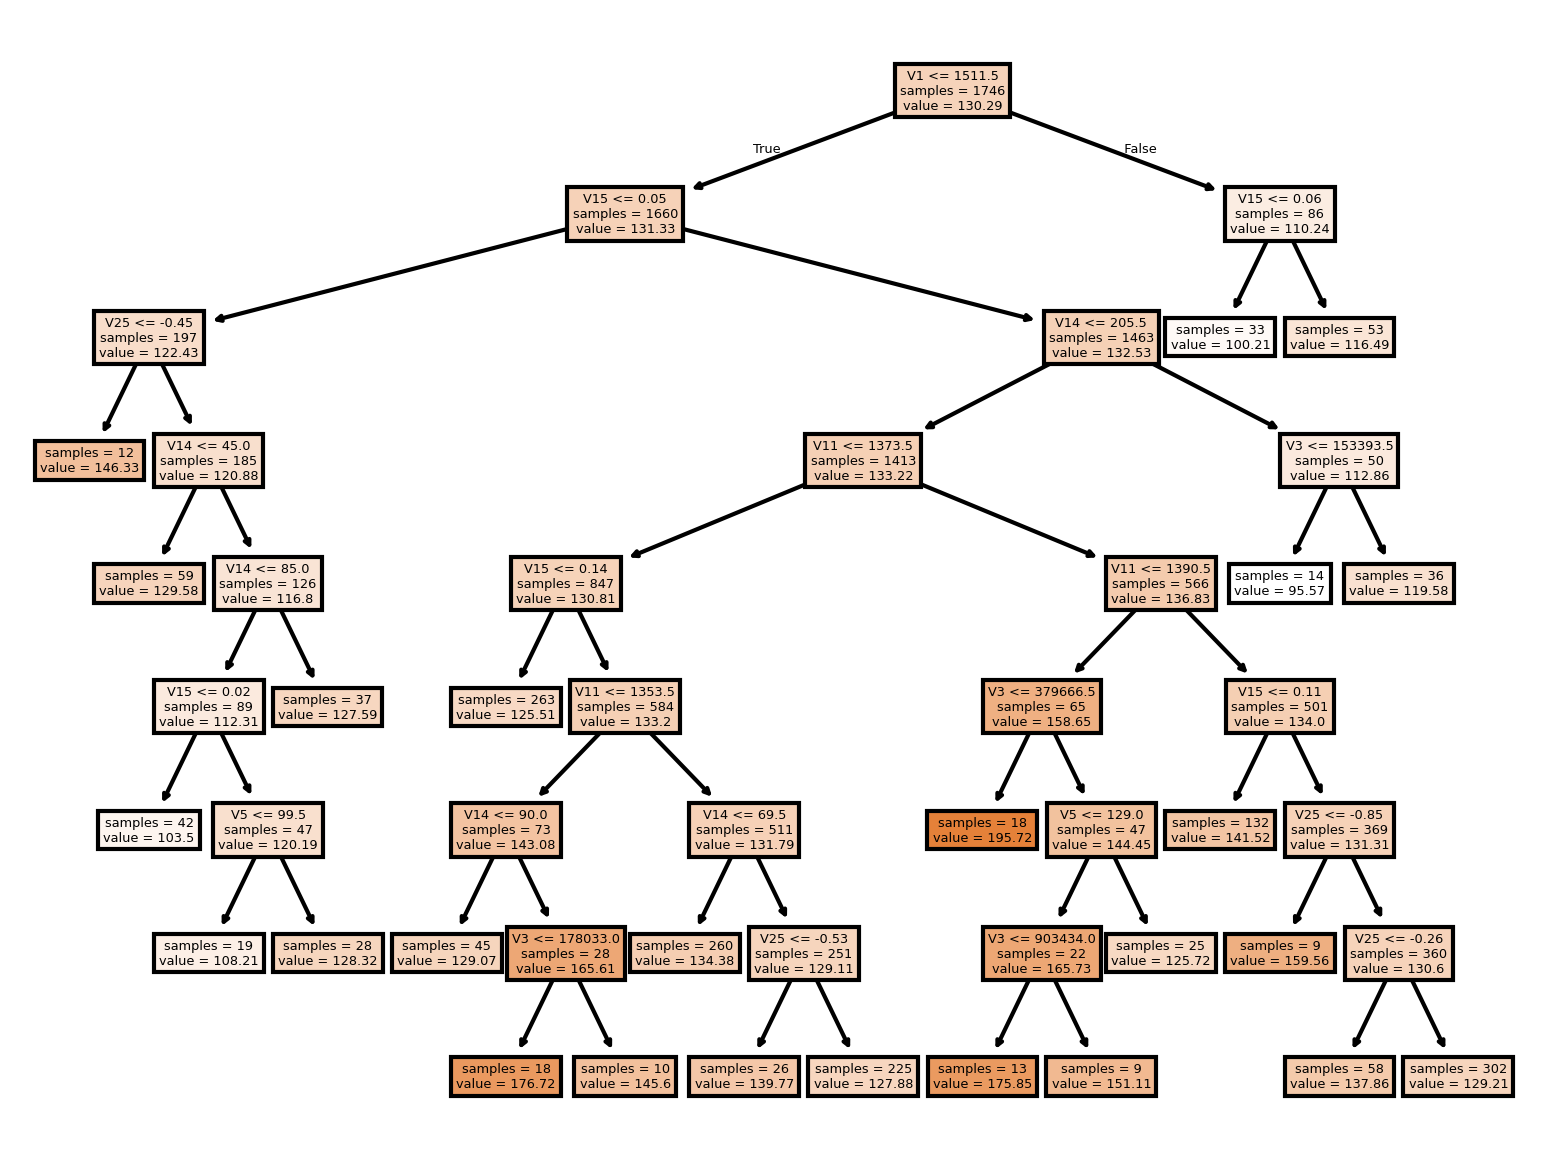

In [122]:
figura, eixo = plt.subplots(dpi=300)
plot_tree(
    modelo_arvore_individual,
    feature_names=ATRIBUTOS,
    ax=eixo,
    impurity=False,
    filled=True,
    proportion=False,
    precision=2,
)
plt.show()

### A Floresta Aleatória

Vamos agora para a Floresta Aleatória! Garantindo as configurações qeu citamos..

In [123]:
# Mesma estrutura utilizada anteriormente, deixada aqui só para registro
TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 42
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_array,
    y_array,
    test_size=TAMANHO_TESTE,
    random_state=SEMENTE_ALEATORIA
)
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

X_treino: (1746, 7)
X_teste: (195, 7)
y_treino: (1746,)
y_teste: (195,)


Vamos agora buscar a melhor combinação das características para nossas árvores e o número delas que traz o melhor resultado dentro dos limites escolhidos!

In [124]:
NUM_FOLDS = 10
NUM_ITERACOES = 500

espaco_de_busca = {
    "n_estimators": range(1, 51),
    "max_depth": range(1, 17),
    "max_leaf_nodes": range(2, 17)
}

modelo = RandomForestRegressor(
    max_features=0.33,
    random_state=42,
    n_jobs=-1
)

buscador = RandomizedSearchCV(
    estimator=modelo,
    param_distributions=espaco_de_busca,
    n_iter=NUM_ITERACOES,
    cv=NUM_FOLDS,
    scoring="neg_root_mean_squared_error",
    refit=True,
    random_state=42,
    n_jobs=-1
)

buscador.fit(X_treino, y_treino)

resultados = pd.DataFrame(
    buscador.cv_results_
)

resultados["rmse_cv"] = (
    -resultados["mean_test_score"]
)

top15 = resultados.nsmallest(
    15,
    "rmse_cv"
).copy()

avaliacoes = []

for _, linha in top15.iterrows():

    modelo_temp = RandomForestRegressor(
        n_estimators=int(linha["param_n_estimators"]),
        max_depth=int(linha["param_max_depth"]),
        max_leaf_nodes=int(linha["param_max_leaf_nodes"]),
        max_features=0.33,
        random_state=42,
        n_jobs=-1
    )

    modelo_temp.fit(X_treino, y_treino)

    y_pred_treino_FA = modelo_temp.predict(X_treino)
    y_pred_teste_FA = modelo_temp.predict(X_teste)

    rmse_treino = root_mean_squared_error(
        y_treino,
        y_pred_treino_FA
    )

    rmse_teste = root_mean_squared_error(
        y_teste,
        y_pred_teste_FA
    )

    avaliacoes.append({
        "arvores": int(linha["param_n_estimators"]),
        "profundidade": int(linha["param_max_depth"]),
        "folhas": int(linha["param_max_leaf_nodes"]),
        "rmse_cv": linha["rmse_cv"],
        "rmse_treino": rmse_treino,
        "rmse_teste": rmse_teste,
        "diferenca": abs(
            rmse_treino - rmse_teste
        )
    })

df_final = pd.DataFrame(avaliacoes)

df_final = df_final.sort_values(
    "rmse_teste"
)

melhor_equilibrado = df_final.loc[
    df_final["diferenca"].idxmin()
]

parametros_melhor_equilibrado = {
    "n_estimators": int(melhor_equilibrado["arvores"]),
    "max_depth": int(melhor_equilibrado["profundidade"]),
    "max_leaf_nodes": int(melhor_equilibrado["folhas"]),
    "max_features": 0.33,
    "random_state": 42,
    "n_jobs": -1
}

print("\nTOP 15 MODELOS\n")

print(
    df_final.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\nMELHOR EQUILIBRADO ENTRE OS 15\n")

print(
    f"Árvores: {int(melhor_equilibrado['arvores'])}\n"
    f"Profundidade: {int(melhor_equilibrado['profundidade'])}\n"
    f"Folhas: {int(melhor_equilibrado['folhas'])}\n"
    f"RMSE CV: {melhor_equilibrado['rmse_cv']:.4f}\n"
    f"RMSE treino: {melhor_equilibrado['rmse_treino']:.4f}\n"
    f"RMSE teste: {melhor_equilibrado['rmse_teste']:.4f}\n"
    f"Diferença: {melhor_equilibrado['diferenca']:.4f}"
)


TOP 15 MODELOS

 arvores  profundidade  folhas  rmse_cv  rmse_treino  rmse_teste  diferenca
      33            12      16  14.8210      13.4005     16.8935     3.4930
      19            11      16  14.7746      13.4069     16.9180     3.5111
      17            10      16  14.7631      13.4352     16.9263     3.4911
      10            13      16  14.8426      13.5769     16.9818     3.4048
      12             7      16  14.9181      13.5979     16.9865     3.3886
      15             9      16  14.7531      13.5514     16.9894     3.4380
      18            13      16  14.7719      13.4298     16.9902     3.5604
      30            16      16  14.7918      13.4213     17.0309     3.6096
      28             9      16  14.8368      13.4695     17.0867     3.6172
      38            12      15  14.9076      13.6080     17.2137     3.6057
      14            13      15  14.8471      13.7218     17.2270     3.5052
      49            16      16  14.8937      13.5121     17.2433     3.

A partir destes testes escolhemos nossa configuração tentando equilibrar o menor overfitting possível para obter um bom valor de RMSE.

In [125]:
modelo_FA = RandomForestRegressor(
    **parametros_melhor_equilibrado
)

modelo_FA.fit(X_treino, y_treino)

y_previsao_FA = modelo_FA.predict(X_teste)

rmse_teste = root_mean_squared_error(
    y_teste,
    y_previsao
)

print(rmse_teste)

15.971730241749931


Vamos plotar e visualizar como os resultados estão se comportando.

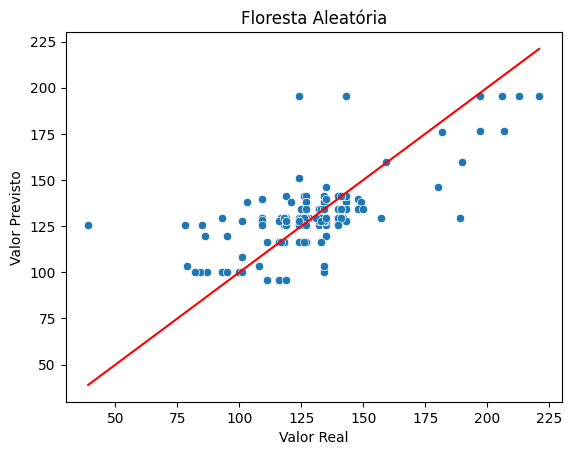

In [126]:
sns.scatterplot(
    x=y_teste,
    y=y_previsao
)

sns.lineplot(
    x=y_teste,
    y=y_teste,
    color="red"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Floresta Aleatória")
plt.show()

Vamos ver qual o atributo que está influenciando mais nosso modelo? Essa distribuição não será interessante caso concentre muita importância em poucos atributos

Text(0.5, 0, 'Atributo')

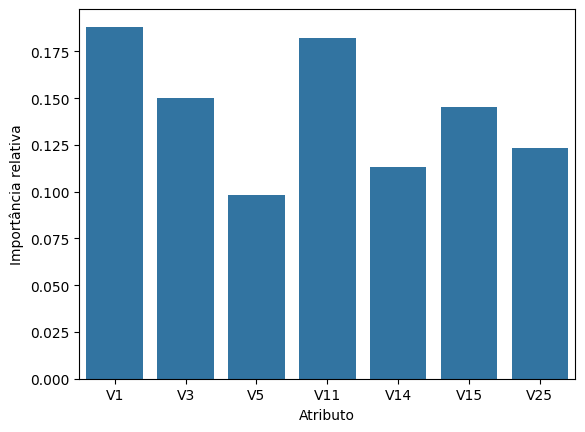

In [128]:
importancia = modelo_FA.feature_importances_

eixo = sns.barplot(
    x=ATRIBUTOS,
    y=importancia
)

eixo.set_ylabel("Importância relativa")
eixo.set_xlabel("Atributo")

### O Baseline

O Baseline é um modelo para termos um"chão" ou seja, entender a partir de quando compensa gastar recursos computacionais para ter um modelo preditivo ou irmos sempre na média (que é o que o Baseline faz)

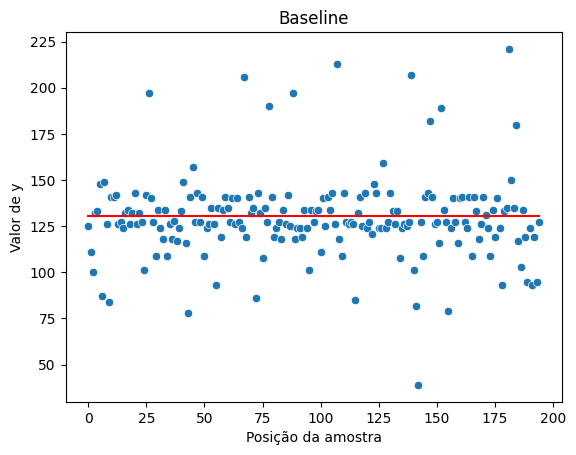

Valor previsto pelo Baseline: 130.2892
RMSE do Baseline: 22.6199


In [129]:
modelo_baseline = DummyRegressor(strategy="mean")
modelo_baseline.fit(X_treino, y_treino)

y_prev_baseline = modelo_baseline.predict(X_teste)
rmse_baseline = root_mean_squared_error(y_teste, y_prev_baseline)

sns.scatterplot(
    x=range(len(y_teste)),
    y=y_teste,
)

sns.lineplot(
    x=range(len(y_teste)),
    y=y_prev_baseline,
    color="red",
)
plt.xlabel("Posição da amostra")
plt.ylabel("Valor de y")
plt.title("Baseline")
plt.show()

print(f'Valor previsto pelo Baseline: {modelo_baseline.constant_.item():.4f}')
print(f'RMSE do Baseline: {rmse_baseline:.4f}')

### O modelo de Comitê

Vamos então criar nosso modelo de comitê! Ele será feito com 500 Bootstraps para vermos o que acontece!

In [130]:
N_BOOTSTRAPS = 500

modelos_bootstrap = []

for i in range(N_BOOTSTRAPS):

    X_boot, y_boot = resample(
        X_treino,
        y_treino,
        replace=True,
        random_state=i
    )

    arvore = DecisionTreeRegressor(
        max_depth=10,
        max_leaf_nodes=16,
        random_state=i
    )

    knn = KNeighborsRegressor(
        n_neighbors=7
    )

    floresta = RandomForestRegressor(
        n_estimators=10,
        max_depth=10,
        max_leaf_nodes=None,
        random_state=i
    )

    arvore.fit(X_boot, y_boot)
    knn.fit(X_boot, y_boot)
    floresta.fit(X_boot, y_boot)

    modelos_bootstrap.append(arvore)
    modelos_bootstrap.append(knn)
    modelos_bootstrap.append(floresta)

Vamos agora comparar nossos modelos de forma individual com o comitê

In [131]:
# Previsões individuais
y_pred_arvore = arvore.predict(X_teste)
y_pred_knn = knn.predict(X_teste)
y_pred_floresta = floresta.predict(X_teste)

# RMSE individuais
rmse_arvore = root_mean_squared_error(y_teste, y_pred_arvore)
rmse_knn = root_mean_squared_error(y_teste, y_pred_knn)
rmse_floresta = root_mean_squared_error(y_teste, y_pred_floresta)

# Comitê (média simples)
y_pred_comite = (
    y_pred_arvore +
    y_pred_knn +
    y_pred_floresta
) / 3

rmse_comite = root_mean_squared_error(
    y_teste,
    y_pred_comite
)

print(f"RMSE Árvore   : {rmse_arvore:.4f}")
print(f"RMSE KNN      : {rmse_knn:.4f}")
print(f"RMSE Floresta : {rmse_floresta:.4f}")
print(f"RMSE Comitê   : {rmse_comite:.4f}")

RMSE Árvore   : 19.5842
RMSE KNN      : 23.3066
RMSE Floresta : 15.5705
RMSE Comitê   : 17.9913


Podemos ver que o modelo da Floresta aleatória se sai melhor que os outros, para tentarmos melhorar isso podemos adotar pesos. Veremos mais sobre esse tipo de ideia na parte relacionada a Meta-Aprendizado.

In [132]:
y_pred_comite_pond = (
    0.7 * y_pred_floresta +
    0.1 * y_pred_arvore +
    0.2 * y_pred_knn
)
rmse_comite_pond = root_mean_squared_error(
    y_teste,
    y_pred_comite_pond
)
print(rmse_comite_pond)

16.309667916489555


### Votação Rigorosa, Votação Suave e formas de agregação

**Formas de Agregação em Problemas Numéricos**

Em problemas numéricos, como os de regressão, os modelos de um comitê produzem **valores numéricos** como previsão.

Por exemplo, diferentes modelos podem prever o preço de uma casa:

- Modelo 1 → R$ 450.000
- Modelo 2 → R$ 480.000
- Modelo 3 → R$ 470.000

O comitê precisa combinar essas previsões para produzir um **único valor final**.

**Combinação**

O processo pode ser representado como:

**Entrada**

↓

**Modelo 1 → previsão numérica**, **Modelo 2 → previsão numérica**, **Modelo 3 → previsão numérica**

↓

**Agregação**

↓

**Previsão numérica final**

A forma de agregação determina como as diferentes previsões serão combinadas.

Em classificação, os modelos podem votar em uma classe.

Em regressão, cada modelo fornece um **valor**.

Por isso, em vez de contar votos, podemos combinar as previsões utilizando operações como:

- média;
- média ponderada;
- mediana;
- outras estratégias de agregação.

A ideia geral continua sendo a mesma

Combinar modelos para uma única resposta

Os pesos representam a importância relativa atribuída a cada modelo.

Um modelo com peso maior exerce maior influência sobre a previsão final.

Isso pode ser útil quando:

- alguns modelos apresentam melhor desempenho;
- alguns modelos são mais confiáveis;
- diferentes modelos possuem diferentes níveis de erro.

Assim, o comitê não precisa tratar todos os modelos necessariamente da mesma maneira.

Outra possibilidade é utilizar a **mediana** das previsões.

Considere:

100, 105, 110, 115, 500

A média seria fortemente influenciada pelo valor 500.

A mediana, entretanto, representa o valor central desse conjunto.

Isso torna a mediana uma alternativa interessante quando existem previsões muito discrepantes entre os modelos.

**Votação Rigorosa (Hard Voting)**

Na votação rigorosa, cada modelo fornece apenas a **classe que considera mais provável**.

O modelo não informa o seu grau de confiança. Ele simplesmente realiza um voto em uma das classes disponíveis.

A decisão final é determinada pela classe que recebe o maior número de votos.

Em outras palavras:

**A classe mais votada pelo conjunto de modelos é escolhida pelo comitê.**

Votação Suave (Soft Voting)

Na votação suave, os modelos não fornecem apenas uma classe.

Eles fornecem também as **probabilidades estimadas para cada classe**.

Dessa forma, o comitê consegue utilizar informações sobre o grau de confiança de cada modelo.

A decisão final é obtida combinando as probabilidades fornecidas pelos modelos.

Em uma implementação comum da votação suave, calcula-se a média das probabilidades fornecidas pelos modelos.

No exemplo anterior:

| Classe | Média das probabilidades |
|---|---:|
| Gato | 0,347 |
| Cachorro | 0,653 |

Assim, o comitê produziria aproximadamente:

**Gato → 34,7%**

**Cachorro → 65,3%**

A classe com maior probabilidade agregada é escolhida como previsão final.

### Meta Aprendizado

**Aprendendo a aprender?**

Até aqui, estudamos diferentes formas de fazer um modelo aprender a partir de dados. Também vimos que podemos combinar vários modelos para formar um comitê, buscando obter decisões mais robustas do que aquelas produzidas por um único modelo.

Mas imagine a seguinte situação:

E se um sistema pudesse aprender com as experiências que teve em problemas anteriores para decidir como aprender um problema novo?
Essa pergunta nos leva a uma ideia mais ampla: o Meta-aprendizado

Podemos fazer um paralelo interessante com o nosso aprendizado:

Imagine você aluno da Ilum em uma aula onde o professor sugere um problema, o explica no quadro e você tenta resolve-lo, conseguindo ou não, você provavelmente você seguiu um caminho semelhante ou igual o que foi sugerido pelo docente. Você repete esse processo todos os dias durante os três anos, ao final do curso é bem provável que com uma base sólida e experiência na resolução de problemas consiga resolver um problema que jamais tenha visto, mas já tenha resolvido problemas na mesma área.

Um professor que tive no fundamnetal uma vez me disse: 

"Na maioria das vezes, você só consegue resolver um problema Matemático se já tiver resolvido um problema semelhante"

Um comitê consegue funcionar de forma análoga, ao resolver centenas de problemas ele pode captar o padrão envolvido e conseguir inferir como ele conseguirá inferir um "caminho" para resolver este problema novo

Ele faz isso por meio de:

determinados modelos funcionam melhor quando os dados possuem certas características;

alguns algoritmos são mais adequados para conjuntos pequenos;

outros funcionam melhor quando existem muitas variáveis;

determinadas configurações tendem a funcionar melhor em determinados tipos de problema;

algumas combinações de modelos são particularmente úteis em certas situações.

Representação do Meta-Aprendizado:

<img alt="célula" src="https://media.licdn.com/dms/image/v2/D4E12AQE9VToue71eSA/article-inline_image-shrink_400_744/article-inline_image-shrink_400_744/0/1680272927556?e=2147483647&v=beta&t=7cfFUz-xY7ojUYFCb3RZ-IHz3MQ1aV2-Z16sWoh81pA" width="800px">

***Fonte: https://pt.linkedin.com/pulse/meta-aprendizagem-contexto-do-aprendizado-de-m%C3%A1quina-gilson-castro***

Mas como isso funciona com o modelo de comitê?

ele se baseia em situações anteriores para tentar deduzir qual ou quais dos modelo disponíveis melhor se encaixa no problema atual, ou seja ele tenta não apenas melhorar a resposta ao problema ele tenta melhorar como ele faz para resolvê-lo

Podemos tentar entender o meta aprendizado como uma progrssão quase que natural do aprendizado de máquina, um modelo aprende com os dados, um comitê combina os aprendizados de diferentes modelos, já o meta aprendizado aprende a otimizar o processo de aprender, por isso "aprender a aprender" pode ser uma boa frase para descrever de forma intuitiva o objetivo do Meta-Aprendizado

Para isso ele usa a ideia de Stacking, onde ele basicamente treina os modelos e depois treina um  Meta-modelo que com base nos resultados é treinado para combinar os modelos para buscar a melhor reposta possível.

In [133]:
# Divide apenas o conjunto de treino original
X_treino_base, X_validacao, y_treino_base, y_validacao = train_test_split(
    X_treino,
    y_treino,
    test_size=0.2,
    random_state=42
)

# Treina os modelos base
arvore.fit(X_treino_base, y_treino_base)
knn.fit(X_treino_base, y_treino_base)
floresta.fit(X_treino_base, y_treino_base)

# Previsões na validação
pred_val_floresta = floresta.predict(X_validacao)
pred_val_arvore = arvore.predict(X_validacao)
pred_val_knn = knn.predict(X_validacao)

# Dados para treinar o meta-modelo
X_meta_treino = np.column_stack([
    pred_val_floresta,
    pred_val_arvore,
    pred_val_knn
])

# Meta-modelo
meta_modelo = LinearRegression()
meta_modelo.fit(X_meta_treino, y_validacao)

# Re-treina os modelos base usando TODO o treino
arvore.fit(X_treino, y_treino)
knn.fit(X_treino, y_treino)
floresta.fit(X_treino, y_treino)

# Previsões no teste
y_pred_floresta = floresta.predict(X_teste)
y_pred_arvore = arvore.predict(X_teste)
y_pred_knn = knn.predict(X_teste)

# Entradas do meta-modelo
X_meta_teste = np.column_stack([
    y_pred_floresta,
    y_pred_arvore,
    y_pred_knn
])

# Previsão final
y_pred_meta = meta_modelo.predict(X_meta_teste)

# RMSEs
rmse_floresta = root_mean_squared_error(y_teste, y_pred_floresta)
rmse_arvore = root_mean_squared_error(y_teste, y_pred_arvore)
rmse_knn = root_mean_squared_error(y_teste, y_pred_knn)
rmse_meta = root_mean_squared_error(y_teste, y_pred_meta)

print(f"RMSE Floresta: {rmse_floresta:.4f}")
print(f"RMSE Árvore:   {rmse_arvore:.4f}")
print(f"RMSE KNN:      {rmse_knn:.4f}")
print(f"RMSE Meta:     {rmse_meta:.4f}")

print("\nPesos aprendidos:")
print(f"Floresta: {meta_modelo.coef_[0]:.4f}")
print(f"Árvore:   {meta_modelo.coef_[1]:.4f}")
print(f"KNN:      {meta_modelo.coef_[2]:.4f}")
print(f"Intercepto: {meta_modelo.intercept_:.4f}")

RMSE Floresta: 15.2425
RMSE Árvore:   16.7740
RMSE KNN:      21.9892
RMSE Meta:     15.3706

Pesos aprendidos:
Floresta: 0.9502
Árvore:   0.0885
KNN:      -0.2120
Intercepto: 22.3422


Podemos perceber que o intercepto é um valor próximo a média e que o nosso modelo aprende a "Deixar de usar" o KNN porque ele entende que ele erra considerávelmente mais do que os outros modelos envolvidos, a contribuição da Floresta Aleatória também se mostra bem maior, indicando esse desnível entre nossos modelos.

Por fim, vamos ver o a relação entre os valores indicados por nosso comitê e os valores reais

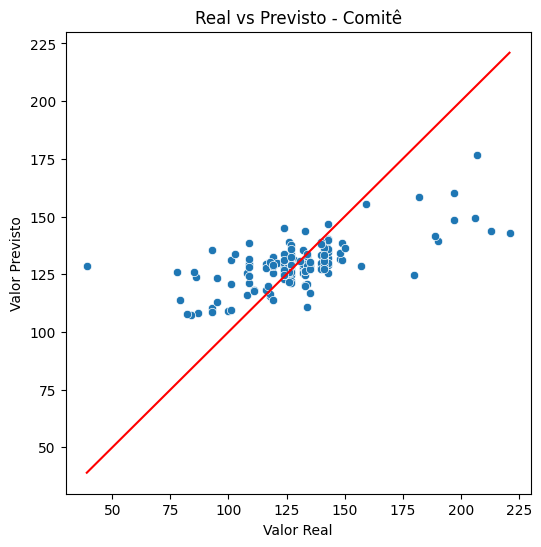

In [134]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_teste,
    y=y_pred_comite
)

plt.plot(
    [y_teste.min(), y_teste.max()],
    [y_teste.min(), y_teste.max()],
    color="red"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Real vs Previsto - Comitê")
plt.show()

### Conclusão

Antes de tudo vamos notar a correlação entre nossos atributos:

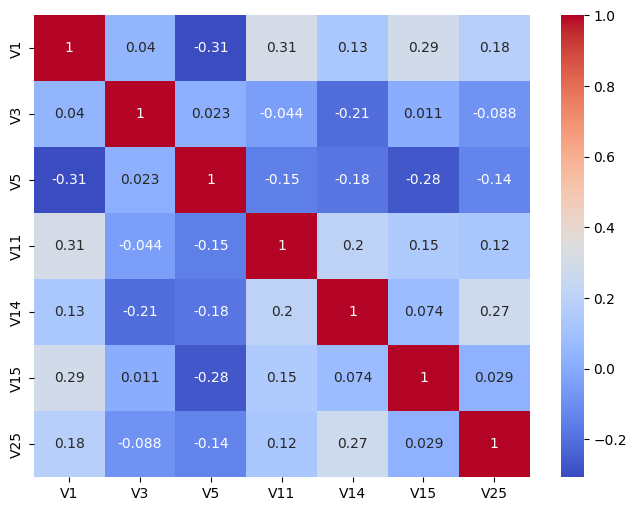

In [135]:
X_df = pd.DataFrame(X_treino, columns=ATRIBUTOS)
plt.figure(figsize=(8,6))
sns.heatmap(X_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Veja que eles são poco correlacionads entre eles, o que é interessante e demonstra que os atributos fornecem diferentes informações para nossos modelos, isso é fundamental para utilizarmos com sabedoria nossos recursos computacionais, já que são limitados

Vamos agora comparar os RMSEs dos nossos modelos que estão no comitê, com o próprio comitê

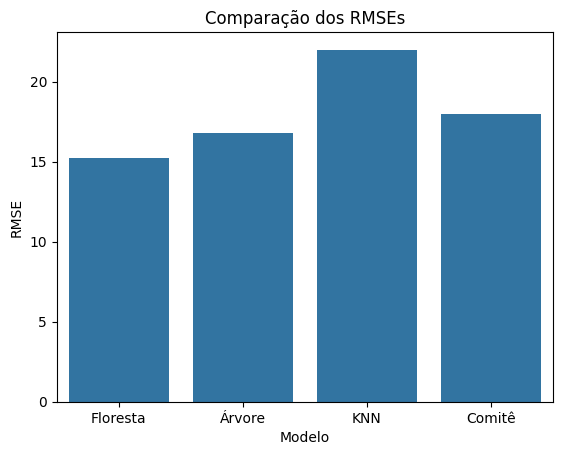

In [136]:
rmses = {
    "Floresta": root_mean_squared_error(y_teste, y_pred_floresta),
    "Árvore": root_mean_squared_error(y_teste, y_pred_arvore),
    "KNN": root_mean_squared_error(y_teste, y_pred_knn),
    "Comitê": root_mean_squared_error(y_teste, y_pred_comite)
}

sns.barplot(
    x=list(rmses.keys()),
    y=list(rmses.values())
)

plt.ylabel("RMSE")
plt.xlabel("Modelo")
plt.title("Comparação dos RMSEs")
plt.show()

O RMSE do comitê é fruto da combinação das predições dos modelos e seus respectivos erros, vemos então a clara interferência do KNN ao "puxar" o RMSE para cima.

Vamos agora ver as previsões de cada modelo em comparação aos valores corretos em um gráfico:

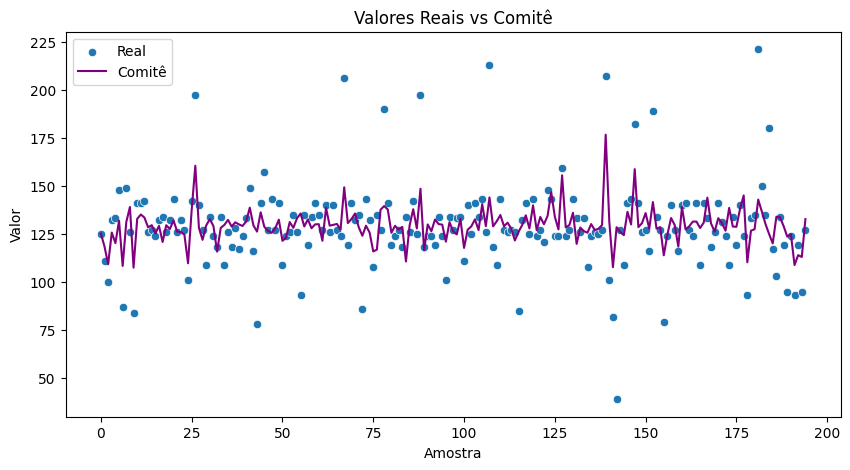

In [137]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=range(len(y_teste)),
    y=y_teste,
    label="Real"
)

sns.lineplot(
    x=range(len(y_teste)),
    y=y_pred_comite,
    color="purple",
    label="Comitê"
)

plt.title("Valores Reais vs Comitê")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.show()

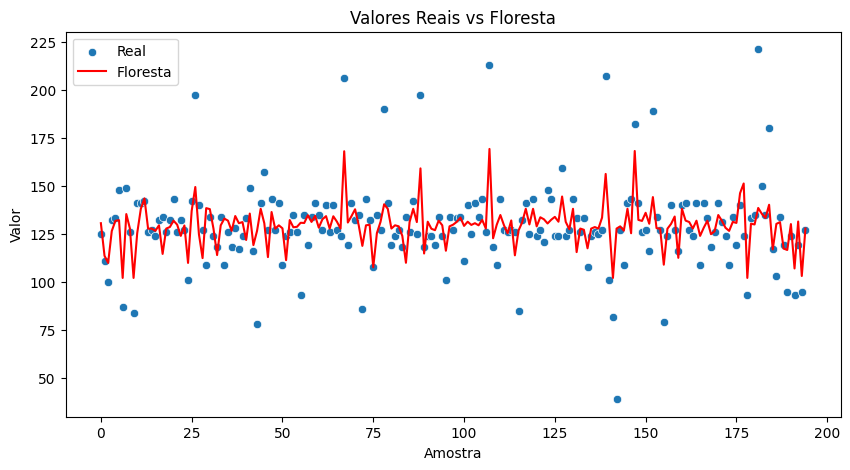

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=range(len(y_teste)),
    y=y_teste,
    label="Real"
)

sns.lineplot(
    x=range(len(y_teste)),
    y=y_previsao_FA,
    color="red",
    label="Floresta"
)

plt.title("Valores Reais vs Floresta")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.show()

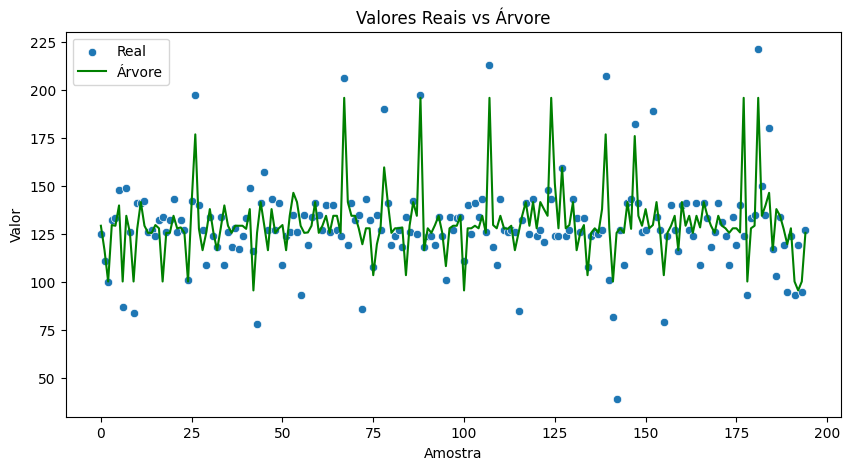

In [138]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=range(len(y_teste)),
    y=y_teste,
    label="Real"
)

sns.lineplot(
    x=range(len(y_teste)),
    y=modelo_arvore_individual.predict(X_teste),
    color="green",
    label="Árvore"
)

plt.title("Valores Reais vs Árvore")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.show()

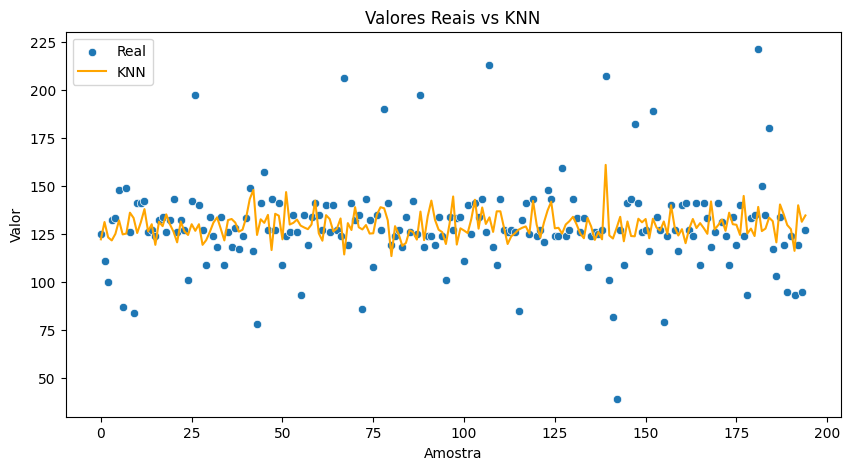

In [ ]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=range(len(y_teste)),
    y=y_teste,
    label="Real"
)

sns.lineplot(
    x=range(len(y_teste)),
    y=y_pred_knn,
    color="orange",
    label="KNN"
)

plt.title("Valores Reais vs KNN")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.show()

No caso abordado neste notebook seria melhor utilizar o modelo de Floresta Aleatória do que o modelo de comitê criado com os integrantes escolhidos. A interpretação deste tipo de situação é importante, nem sempre o modelo de comitê é a resposta. Se ainda estiver com dúvidas quanto a isso, retorne ao tópico que falamos sobre as limitações do modelo de comitê.

**Considerações importantes**

Este é um notebook didático para o entendimento geral e introdutório do que são modelos de comitê e o que é o Meta aprendizado. Os resultados exemplificados sofreram com aplicações desses conceitos em situações não ideais, como modelos semelhantes (Floresta Aleatória e Árvore de decisão), modelos que possuem uma considerável diferença de desempenho entre si em um mesmo comitê, além de dados pouco dispersos.

### Utilização de IA no desenvolvimento do trabalho

A IA utilizada neste trabalho foi de suma importância para facilitar a pesquisa de referências bibliográficas, além de auxiliar na escrita de alguns símbolos matemáticos, discussão para o entendimento de alguns conceitos e criação de códigos.

Vale ressaltar que todo o conteúdo deste notebook que foi feito com contribuição de IA foi devidamente entendido e revisado pelo autor.

### Referências:

BREIMAN, Leo. Bagging predictors. Machine Learning, Dordrecht, v. 24, n. 2, p. 123-140, 1996. Disponível em: <https://www.stat.berkeley.edu/~breiman/bagging.pdf>.

IZBICKI, Rafael; SANTOS, Tiago Mendonça dos. Aprendizado de máquina: uma abordagem estatística. 1. ed. Curitiba: Alta Books, 2020.

SCIKIT-LEARN. 1.11. Ensembles: Gradient boosting, random forests, bagging, voting, stacking. Scikit-learn Documentation, [S. l.], 2025. Disponível em: <https://scikit-learn.org/stable/modules/ensemble.html>.

KUMAR, Rahul. Bagging. In: KUMAR, Rahul. Machine Learning Quick Reference. Birmingham: Packt Publishing, 2019. Disponível em: <https://www.oreilly.com/library/view/machine-learning-quick/9781788830577/6f97f4fd-5b34-4d7b-bb48-ec156c6262b1.xhtml>

Conjunto de dados fornecido por Semeion, Centro de Pesquisa em Ciências da Comunicação, via Sersale 117, 00128, Roma, Itália. Disponível em: <https://www.openml.org/search?type=data&sort=runs&status=active&id=1504>

CASTRO, Gilson. Meta-aprendizagem no contexto do aprendizado de máquina. LinkedIn, [s.d.]. Disponível em: <https://pt.linkedin.com/pulse/meta-aprendizagem-contexto-do-aprendizado-de-m%C3%A1quina-gilson-castro>.